# Micelle correction on/off, at the measured TDCR

A short, self-contained check: for each nuclide a **measured** triple-to-double
ratio is given, `L` is fitted to reproduce it twice — once with the micellar
correction and once without — and the two answers are compared.

This is how an activity measurement actually works. `L` is never imposed; it is
deduced from the ratio the counter reports. So the question is not "how much
light does the water remove" but **how wrong is the efficiency you report if
you deduce `L` with the wrong model**.

| | |
|---|---|
| Micelle diameter | 4 nm (the kernel uses the radius, 2 nm) |
| `sigma_micelle` | 0 — monodisperse |
| Aqueous fraction | 10 % water in Ultima Gold |
| Birks constant | 0.01 cm/MeV = 1e-5 cm/keV |
| MC trials | 500 000 (the fit); 3 000 for the timing ratio |

| nuclide | measured TDCR |
|---|---|
| ³H | 0.668 |
| ⁵⁵Fe | 0.570 |
| ⁵¹Cr | 0.477 |
| ⁶³Ni | 0.881 |
| ¹⁴C | 0.970 |
| ⁹⁹Tc | 0.980 |

**Why most of the correction cancels.** If the correction were a uniform loss
of light, $f(E) = F$ at every energy, the uncorrected model would reproduce it
exactly with $L_{\text{uncorr}} = F\,L_{\text{corr}}$ — same photon budget per
decay, same efficiency. The two models would be **exactly degenerate** and
omitting the correction would cost nothing at all. The bulk dilution,
$1-f_{Aq}$, is of that kind.

What is left is the part where the retention *varies across the spectrum*: the
confinement region below ~3 keV, where the electron range is comparable to a
droplet. That is what this notebook measures.


In [1]:
import importlib, io, contextlib, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import norm
from importlib.metadata import version

import tdcrpy.TDCR_model_lib as tl
import tdcrpy.TDCRPy as tm

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
print(f'TDCRPy {version("TDCRPy")}')

TDCRPy 2.20.28


In [2]:
# ---- conditions --------------------------------------------------------
KB       = 1e-5         # cm/keV == 0.01 cm/MeV
V        = 10           # mL
N        = 500000       # MC trials for the fit. At 1e4 no efficiency bias
                        # was resolved -- every one sat within about 1.5 sigma
                        # of zero -- so the statistics, not the physics, were
                        # the limit. This is ~7x tighter than that.
FAQ      = 0.10         # aqueous volume fraction
DIAM     = 4            # nm, micelle DIAMETER (kernel uses radius = DIAM/2)
SIGMA    = 0.0          # monodisperse
COCKTAIL = 'Ultima Gold'

# Measured triple-to-double ratios.
TD_MEAS = {'H-3': 0.668, 'Fe-55': 0.570, 'Cr-51': 0.477,
           'Ni-63': 0.881, 'C-14': 0.970, 'Tc-99': 0.980}
NUCLIDES = list(TD_MEAS)

COLORS = {'H-3': '#d62728', 'Fe-55': '#ff7f0e', 'Cr-51': '#8c564b',
          'Ni-63': '#2ca02c', 'C-14': '#1f77b4', 'Tc-99': '#9467bd'}

# L grid for the fit. It stops at 20 on purpose: above roughly that the
# modelled TDCR turns over for the EC nuclides -- their escaping X-rays leave
# many near-zero deposits that the doubles recover long before the triples can
# -- so a search over a wider range can settle on the falling branch and return
# an L reproducing the wrong ratio. Staying on the rising branch avoids it.
LBOUNDS = (1.0, 20.0)

NOMINAL = dict(fAq=tl.fAq, micCorr=tl.micCorr,
               diam=tl.diam_micelle, sigma=tl.sigma_micelle)


def set_state(micCorr):
    """Write the configuration and reload so the change takes effect.

    Since TDCRPy 2.20.22 the micelle kernel reads fAq, diam_micelle and
    sigma_micelle from the configuration on every call; the reload is still
    needed for the cocktail composition (density, Z, A), which is bound at
    import."""
    global tl, tm
    with contextlib.redirect_stdout(io.StringIO()):
        tl.modifyLScocktail(COCKTAIL, FAQ, 'Water', 0.0)
    tl.modifyDiam_micelle(DIAM)
    tl.modifySigma_micelle(SIGMA)
    tl.modifyMicCorr(bool(micCorr))
    tl = importlib.reload(tl)
    tm = importlib.reload(tm)


set_state(False)
print(f'{COCKTAIL} + {FAQ:.0%} water -> rho={tl.RHO:.4f} g/cm3, '
      f'Z={tl.Z:.4f}, A={tl.A:.4f}')
print(f'micelles: diameter {tl.diam_micelle} nm (radius '
      f'{tl.diam_micelle/2} nm), sigma {tl.sigma_micelle} nm')
print(f'kB = {KB} cm/keV, V = {V} mL, N = {N}')

Ultima Gold + 10% water -> rho=0.9818 g/cm3, Z=3.2597, A=5.9509
micelles: diameter 4.0 nm (radius 2.0 nm), sigma 0.0 nm
kB = 1e-05 cm/keV, V = 10 mL, N = 500000


## 1. Fitting `L` to each measured ratio

`eff()` runs one Monte-Carlo pass per nuclide and arm, then replays those
cached decay histories while it searches for the `L` that reproduces the
measured ratio — so the expensive simulation happens once per arm.

Each fit is checked against the ratio it was asked for, and reported with
`u_L`, the Monte-Carlo uncertainty of the fitted light yield.


In [3]:
import json, os

fit = {}
CACHE = 'micelleCheck_fits.json'

# The conditions the cached fits were produced under. If any of them differ
# the cache is ignored and the fit is recomputed -- a stale cache is worse
# than a slow notebook.
CACHE_KEY = dict(N=N, FAQ=FAQ, DIAM=DIAM, SIGMA=SIGMA, KB=KB, V=V,
                 TD_MEAS=TD_MEAS, tdcrpy=version('TDCRPy'))
_cached = {}
if os.path.exists(CACHE):
    with open(CACHE, encoding='utf-8') as _fh:
        _blob = json.load(_fh)
    if _blob.get('key') == CACHE_KEY:
        _cached = _blob['fits']
        print(f'cache {CACHE}: {len(_cached)} fits match these conditions')
    else:
        print(f'cache {CACHE} was made under different conditions -- ignored')
else:
    print(f'no cache at {CACHE}; every fit will be computed')


def _save_cache():
    with open(CACHE, 'w', encoding='utf-8') as fh:
        json.dump({'key': CACHE_KEY,
                   'fits': {f'{r}|{m}': dict(L=v['L'], uL=v['uL'],
                                             D=v['D'], uD=v['uD'],
                                             tdcr=v['tdcr'])
                            for (r, m), v in fit.items()}},
                  fh, indent=1, sort_keys=True)


def fit_one(rad):
    """Fit L to this nuclide's measured ratio, with and without micCorr.

    Called one nuclide per cell below. Fe-55 and Cr-51 are an order of
    magnitude slower than the rest -- their Auger cascades mean many more
    particles per decay -- and at this N each takes hours. Separate cells mean
    the notebook is checkpointed after each nuclide, so an interruption costs
    one of them rather than the whole run.
    """
    for mic in (False, True):
        t0 = time.time()
        hit = _cached.get(f'{rad}|{mic}')
        if hit is not None:
            fit[(rad, mic)] = dict(L=hit['L'], uL=hit['uL'], D=hit['D'],
                                   uD=hit['uD'], tdcr=hit['tdcr'],
                                   ok=abs(hit['tdcr'] - TD_MEAS[rad]) < 1e-3)
            print(f'{rad:6s} micCorr={str(mic):5s}  L = {hit["L"]:7.4f} '
                  f'+- {hit["uL"]:.4f}  eff_D = {hit["D"]:.5f} '
                  f'+- {hit["uD"]:.5f}  (cached)', flush=True)
            continue
        set_state(mic)
        # eff() records one pass, then replays those cached histories while it
        # searches for L. Since TDCRPy 2.20.23 it also returns u_L, the
        # Monte-Carlo uncertainty of the fitted light yield: the counting
        # uncertainty of the modelled ratio divided by the local slope
        # d(T/D)/dL. Near saturation that slope is small and u_L is large --
        # reading Delta_L without it would be reading noise.
        r = tm.eff(TD_MEAS[rad], rad, '1', KB, V, N=N, L=2.0, Lbounds=LBOUNDS)
        L_fit, uL, D_fit, uD_fit = r[0], r[16], r[4], r[5]
        tdcr_fit = r[6] / r[4] if r[4] > 0 else np.nan
        ok = abs(tdcr_fit - TD_MEAS[rad]) < 1e-3
        fit[(rad, mic)] = dict(L=L_fit, uL=uL, D=D_fit, uD=uD_fit,
                               tdcr=tdcr_fit, ok=ok)
        _save_cache()
        print(f'{rad:6s} micCorr={str(mic):5s}  L = {L_fit:7.4f} +- {uL:.4f}  '
              f'eff_D = {D_fit:.5f} +- {uD_fit:.5f}  '
              f'(fitted TDCR {tdcr_fit:.5f})'
              f'{"" if ok else "   *** FIT DID NOT CONVERGE ***"}'
              f'   [{time.time()-t0:.0f} s]', flush=True)

no cache at micelleCheck_fits.json; every fit will be computed


In [4]:
fit_one('H-3')

H-3    micCorr=False  L =  6.1140 +- 0.0083  eff_D = 0.70025 +- 0.00048  (fitted TDCR 0.66800)   [944 s]


H-3    micCorr=True   L =  6.7480 +- 0.0090  eff_D = 0.69552 +- 0.00049  (fitted TDCR 0.66800)   [1969 s]


In [5]:
fit_one('Ni-63')

Ni-63  micCorr=False  L =  6.0653 +- 0.0171  eff_D = 0.86186 +- 0.00040  (fitted TDCR 0.88100)   [804 s]


Ni-63  micCorr=True   L =  6.6825 +- 0.0186  eff_D = 0.85953 +- 0.00041  (fitted TDCR 0.88100)   [1163 s]


In [6]:
fit_one('C-14')

C-14   micCorr=False  L =  6.1551 +- 0.0301  eff_D = 0.96367 +- 0.00022  (fitted TDCR 0.97000)   [670 s]


C-14   micCorr=True   L =  6.7278 +- 0.0326  eff_D = 0.96281 +- 0.00023  (fitted TDCR 0.97000)   [1141 s]


In [7]:
fit_one('Tc-99')

Tc-99  micCorr=False  L =  4.8718 +- 0.0318  eff_D = 0.97500 +- 0.00019  (fitted TDCR 0.98000)   [724 s]


Tc-99  micCorr=True   L =  5.3829 +- 0.0354  eff_D = 0.97469 +- 0.00019  (fitted TDCR 0.98000)   [1292 s]


In [8]:
fit_one('Fe-55')

Fe-55  micCorr=False  L =  5.5943 +- 0.0004  eff_D = 0.78679 +- 0.00041  (fitted TDCR 0.57000)   [14567 s]


Fe-55  micCorr=True   L =  6.5228 +- 0.0008  eff_D = 0.78458 +- 0.00041  (fitted TDCR 0.57000)   [15884 s]


In [9]:
fit_one('Cr-51')

Cr-51  micCorr=False  L =  5.6020 +- 0.0014  eff_D = 0.72913 +- 0.00036  (fitted TDCR 0.47700)   [17075 s]


Cr-51  micCorr=True   L =  6.6320 +- 0.0018  eff_D = 0.72468 +- 0.00036  (fitted TDCR 0.47700)   [16334 s]


In [10]:
bad = [k for k, v in fit.items() if not v['ok']]
missing = [(r, m) for r in NUCLIDES for m in (False, True)
           if (r, m) not in fit]
print('All fits reproduce their measured ratio.' if not bad
      else f'NOT CONVERGED, results meaningless for: {bad}')
if missing:
    print(f'MISSING -- a fit cell did not run: {missing}')

All fits reproduce their measured ratio.


## 2. The result: same measured ratio, two efficiencies

Both arms are pinned to the **same** measurement, so each nuclide contributes
two points on one vertical line: the efficiency the uncorrected model reports
(circle) and the efficiency the corrected model reports (square). The
comparison is read **vertically** — there is no `L` left in it, because `L` has
already been fitted away in both arms.

If the correction were a uniform loss of light the two points would coincide:
the uncorrected model would reproduce the corrected one exactly at
$L_{\text{uncorr}} = F\,L_{\text{corr}}$, same photon budget, same
efficiency. Any visible gap is the part no refit can absorb.

Error bars are the Monte-Carlo uncertainty on each efficiency. A gap smaller
than them is not a result.


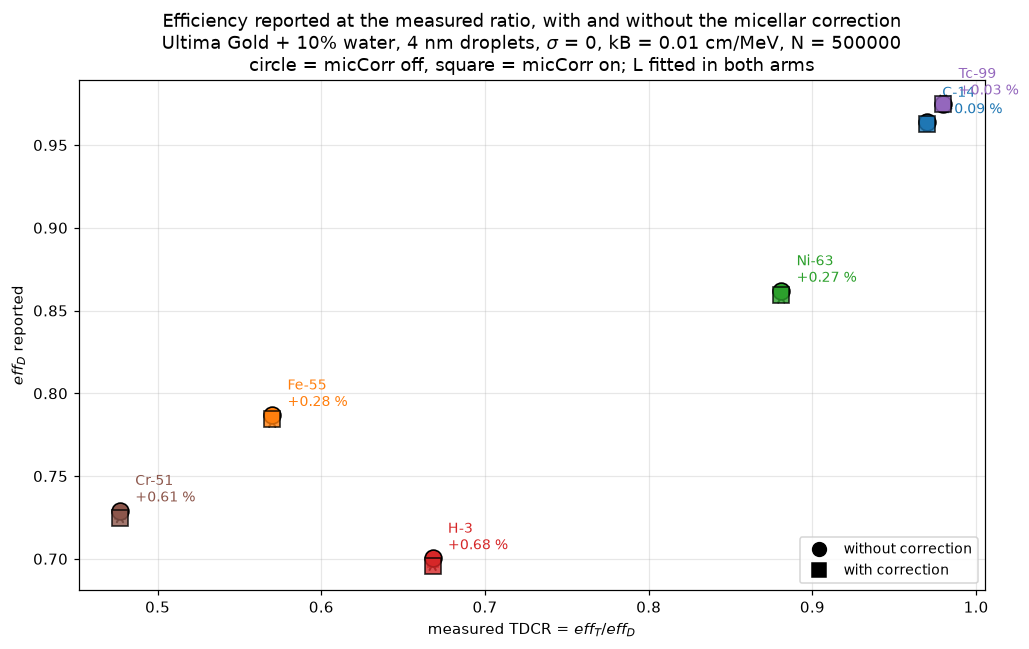

In [11]:
fig, ax = plt.subplots(figsize=(9.5, 6))
for rad in NUCLIDES:
    unc, corr = fit[(rad, False)], fit[(rad, True)]
    t = TD_MEAS[rad]
    ax.errorbar(t, unc['D'], yerr=unc['uD'], fmt='o', ms=11,
                color=COLORS[rad], markeredgecolor='k', markeredgewidth=1.1,
                capsize=4, zorder=5)
    ax.errorbar(t, corr['D'], yerr=corr['uD'], fmt='s', ms=11,
                color=COLORS[rad], markeredgecolor='k', markeredgewidth=1.1,
                capsize=4, alpha=0.8, zorder=5)
    ax.annotate('', xy=(t, corr['D']), xytext=(t, unc['D']),
                arrowprops=dict(arrowstyle='<->', color='#222222', lw=1.4))
    ax.annotate(f'{rad}\n{100*(unc["D"]-corr["D"])/corr["D"]:+.2f} %',
                (t, max(unc['D'], corr['D'])), textcoords='offset points',
                xytext=(10, 6), fontsize=9, color=COLORS[rad])

ax.set_xlabel('measured TDCR = $eff_T / eff_D$')
ax.set_ylabel('$eff_D$ reported')
ax.set_title('Efficiency reported at the measured ratio, with and without the '
             'micellar correction\n'
             f'{COCKTAIL} + {FAQ:.0%} water, {DIAM} nm droplets, '
             f'$\\sigma$ = {SIGMA:g}, kB = 0.01 cm/MeV, N = {N}\n'
             'circle = micCorr off, square = micCorr on; L fitted in both arms')
ax.grid(alpha=0.3)
ax.legend(handles=[
    Line2D([], [], color='k', marker='o', ls='none', ms=9,
           markeredgecolor='k', label='without correction'),
    Line2D([], [], color='k', marker='s', ls='none', ms=9,
           markeredgecolor='k', label='with correction')],
    fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('micelleCheck_effD_vs_TDCR.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. The numbers

`Delta_L` is how much more light yield the corrected model needs to reproduce
the same ratio. `bias` is what is left in the efficiency once that refit has
happened — the error you make by reporting the uncorrected number. Activity is
inversely proportional to efficiency, so its bias has the opposite sign.


In [12]:
print(f'{"nuclide":8s} {"TDCR":>6s} | {"L uncorr":>16s} {"L corr":>16s} '
      f'{"Delta_L %":>10s} {"+-":>6s} | {"eff_D uncorr":>13s} '
      f'{"eff_D corr":>11s} {"bias %":>8s} {"+-":>6s} | {"act. bias %":>12s}')
print('-' * 128)
summary = {}
for rad in NUCLIDES:
    unc, corr = fit[(rad, False)], fit[(rad, True)]
    dL = 100 * (corr['L'] - unc['L']) / unc['L']
    # both fitted L values carry Monte-Carlo uncertainty; propagate to the ratio
    udL = 100 * np.hypot(corr['uL'] / unc['L'],
                         corr['L'] * unc['uL'] / unc['L'] ** 2)
    bias = 100 * (unc['D'] - corr['D']) / corr['D']
    ubias = 100 * np.hypot(unc['uD'], corr['uD']) / corr['D']
    abias = 100 * (corr['D'] / unc['D'] - 1.0)
    summary[rad] = dict(dL=dL, udL=udL, bias=bias, ubias=ubias, abias=abias)
    print(f'{rad:8s} {TD_MEAS[rad]:6.3f} | '
          f'{unc["L"]:9.4f}+-{unc["uL"]:<6.4f} '
          f'{corr["L"]:9.4f}+-{corr["uL"]:<6.4f} '
          f'{dL:10.2f} {udL:6.2f} | {unc["D"]:13.5f} {corr["D"]:11.5f} '
          f'{bias:8.2f} {ubias:6.2f} | {abias:12.2f}')

print(f'\nPure dilution would need Delta_L = 1/(1-fAq) - 1 = '
      f'{100*(1/(1-FAQ)-1):.1f} %. Anything above that is confinement:')
print('electrons slow enough to be trapped inside a droplet and never reach')
print('the solvent. Anything at or below it is light the water simply dilutes,')
print('which the fitted L absorbs completely.')
print(f'\nAt N = {N} the uncertainty on each eff_D is a few parts in a '
      f'thousand, so a bias')
print('smaller than its "+-" column is not resolved. Raise N before ranking '
      'the small ones.')

nuclide    TDCR |         L uncorr           L corr  Delta_L %     +- |  eff_D uncorr  eff_D corr   bias %     +- |  act. bias %
--------------------------------------------------------------------------------------------------------------------------------
H-3       0.668 |    6.1140+-0.0083    6.7480+-0.0090      10.37   0.21 |       0.70025     0.69552     0.68   0.10 |        -0.68
Fe-55     0.570 |    5.5943+-0.0004    6.5228+-0.0008      16.60   0.02 |       0.78679     0.78458     0.28   0.07 |        -0.28
Cr-51     0.477 |    5.6020+-0.0014    6.6320+-0.0018      18.39   0.04 |       0.72913     0.72468     0.61   0.07 |        -0.61
Ni-63     0.881 |    6.0653+-0.0171    6.6825+-0.0186      10.17   0.44 |       0.86186     0.85953     0.27   0.07 |        -0.27
C-14      0.970 |    6.1551+-0.0301    6.7278+-0.0326       9.30   0.75 |       0.96367     0.96281     0.09   0.03 |        -0.09
Tc-99     0.980 |    4.8718+-0.0318    5.3829+-0.0354      10.49   1.02 |       0.97500

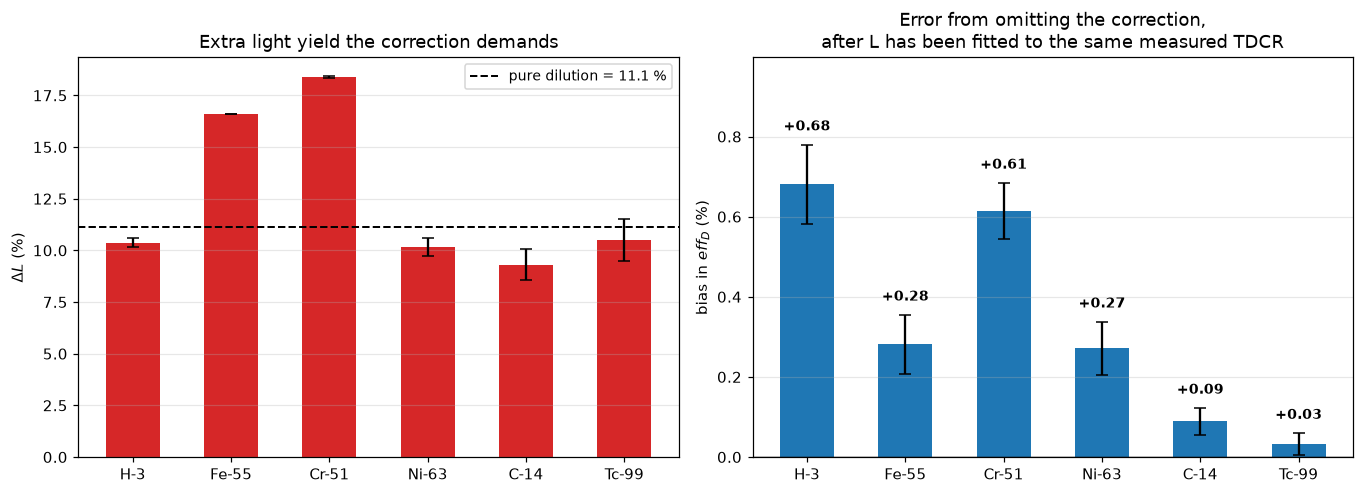

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
x = np.arange(len(NUCLIDES))

axes[0].bar(x, [summary[r]['dL'] for r in NUCLIDES], 0.55, color='#d62728',
            yerr=[summary[r]['udL'] for r in NUCLIDES], capsize=4)
axes[0].axhline(100 * (1 / (1 - FAQ) - 1), color='k', ls='--', lw=1.3,
                label=f'pure dilution = {100*(1/(1-FAQ)-1):.1f} %')
axes[0].set_xticks(x); axes[0].set_xticklabels(NUCLIDES)
axes[0].set_ylabel(r'$\Delta L$ (%)')
axes[0].set_title('Extra light yield the correction demands')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

b = [summary[r]['bias'] for r in NUCLIDES]
ub = [summary[r]['ubias'] for r in NUCLIDES]
axes[1].bar(x, b, 0.55, yerr=ub, capsize=4, color='#1f77b4')
axes[1].axhline(0, color='k', lw=0.9)
axes[1].set_xticks(x); axes[1].set_xticklabels(NUCLIDES)
axes[1].set_ylabel(r'bias in $eff_D$ (%)')
axes[1].set_title('Error from omitting the correction,\nafter L has been '
                  'fitted to the same measured TDCR')
axes[1].grid(axis='y', alpha=0.3)
span = max(abs(min(b)), abs(max(b))) or 1.0
for xi, (v, u) in enumerate(zip(b, ub)):
    axes[1].text(xi, v + (u if v >= 0 else -u) + 0.04 * span * np.sign(v or 1),
                 f'{v:+.2f}', ha='center',
                 va='bottom' if v >= 0 else 'top', fontsize=9,
                 fontweight='bold')
axes[1].margins(y=0.28)

plt.tight_layout()
plt.savefig('micelleCheck_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. What the correction costs

An order of magnitude, nothing more: efficiency at one fixed `L`, both modes,
1000 decays. The correction is applied per electron while the decay is being
quenched, so it is paid in the simulation and not in the replays.

Each arm is given a warm-up call first, because `set_state()` reloads the
module and numba then has to recompile — charging that to whichever arm runs
first is how an earlier version of this cell reported a 56x inflation for
C-14. Three repeats, best of, since single-shot timings on a loaded machine
are not reproducible.


In [14]:
N_COST, L_COST, REPEATS = 1000, 6.0, 3

timing = {}
print(f'{"nuclide":8s} {"t off (s)":>10s} {"t on (s)":>10s} {"factor":>8s}   '
      f'(L = {L_COST:g}, N = {N_COST}, best of {REPEATS})')
print('-' * 62)
for rad in NUCLIDES:
    best = {}
    for mic in (False, True):
        set_state(mic)
        tm.TDCRPy(L_COST, rad, '1', 20, KB, V)        # absorb the compile
        ts = []
        for _ in range(REPEATS):
            t0 = time.time()
            tm.TDCRPy(L_COST, rad, '1', N_COST, KB, V)
            ts.append(time.time() - t0)
        best[mic] = min(ts)
    timing[rad] = dict(off=best[False], on=best[True],
                       factor=best[True] / best[False] if best[False] > 0
                       else np.nan)
    print(f'{rad:8s} {best[False]:10.2f} {best[True]:10.2f} '
          f'{timing[rad]["factor"]:7.2f}x', flush=True)

print('\nRead these as an order of magnitude. The factor is largest where the')
print('uncorrected simulation is cheapest, so it says more about the baseline')
print('than about the correction; the absolute extra time tracks the number of')
print('electrons per decay, which is what the kernel is called on.')

nuclide   t off (s)   t on (s)   factor   (L = 6, N = 1000, best of 3)
--------------------------------------------------------------


H-3            1.61       1.92    1.19x


Fe-55         28.10      28.56    1.02x


Cr-51         28.04      28.48    1.02x


Ni-63          0.80       1.15    1.45x


C-14           0.34       0.69    2.04x


Tc-99          0.37       1.05    2.84x



Read these as an order of magnitude. The factor is largest where the
uncorrected simulation is cheapest, so it says more about the baseline
than about the correction; the absolute extra time tracks the number of
electrons per decay, which is what the kernel is called on.


## 5. Summary, with a test on each difference

Two different questions, so two tests.

**Is the reported efficiency wrong?** `Delta_eff_D` against zero, as a two-sided
z-test. This is what matters for a measurement.

**Is there confinement?** Here a test against zero would be meaningless —
every nuclide shifts `L` because the water dilutes the cocktail. The question
is whether `Delta_L` differs from the dilution value $1/(1-f_{Aq})-1$ = 11.1 %.
The interval `Delta_L` ± 2σ is compared with that value: if it contains 11.1 %
the shift is dilution alone; if it lies entirely above, confinement is
resolved; if entirely below, something else is at work and the table says so
rather than calling it confinement.

Six nuclides are tested at once, so the efficiency test uses the
Bonferroni-corrected threshold 0.05/6 ≈ 0.0083.


In [15]:
DIL = 100 * (1 / (1 - FAQ) - 1)          # Delta_L expected from dilution alone
ALPHA_C = 0.05 / len(NUCLIDES)           # Bonferroni, six simultaneous tests


def dL_verdict(dL, u):
    """Compare the Delta_L interval with the pure-dilution value."""
    lo, hi = dL - 2 * u, dL + 2 * u
    if lo <= DIL <= hi:
        return 'dilution only'
    return 'CONFINEMENT' if lo > DIL else 'below dilution'


print('A. Is the reported efficiency wrong without the correction?'
      '   (Delta_eff_D vs 0)\n')
print(f'{"nuclide":8s} {"Delta_eff_D %":>14s} {"+-":>6s} {"z":>7s} {"p":>10s} '
      f'{"significant":>12s}')
print('-' * 62)
for rad in NUCLIDES:
    s = summary[rad]
    z = s['bias'] / s['ubias'] if s['ubias'] > 0 else np.nan
    p = 2 * norm.sf(abs(z))
    s['z_eff'], s['p_eff'] = z, p
    s['v_eff'] = 'yes' if p < ALPHA_C else ('marginal' if p < 0.05 else 'no')
    print(f'{rad:8s} {s["bias"]:14.3f} {s["ubias"]:6.3f} {z:7.2f} {p:10.2e} '
          f'{s["v_eff"]:>12s}')
print(f'\nthreshold p < {ALPHA_C:.4f} (Bonferroni, {len(NUCLIDES)} tests)')

print(f'\n\nB. Is the light-yield shift more than dilution?'
      f'   (Delta_L vs {DIL:.2f} %)\n')
print(f'{"nuclide":8s} {"Delta_L %":>10s} {"+-":>6s} '
      f'{"2-sigma interval":>20s} {"verdict":>16s}')
print('-' * 62)
for rad in NUCLIDES:
    s = summary[rad]
    s['v_L'] = dL_verdict(s['dL'], s['udL'])
    lo, hi = s['dL'] - 2 * s['udL'], s['dL'] + 2 * s['udL']
    print(f'{rad:8s} {s["dL"]:10.2f} {s["udL"]:6.2f} '
          f'{f"[{lo:6.2f}, {hi:6.2f}]":>20s} {s["v_L"]:>16s}')
print(f'\n"dilution only"  the interval contains {DIL:.2f} %: the shift in L is')
print('                 the water diluting the cocktail, nothing more.')
print('"CONFINEMENT"    the interval lies entirely above it.')
print('"below dilution" entirely below -- not confinement. The correction also')
print('                 injects a per-decay dispersion in the retained energy,')
print('                 which acts on the T/D ratio and can reduce the L needed.')

print('\n\nC. Everything together\n')
print(f'{"nuclide":8s} {"TDCR":>6s} {"Delta_L %":>10s} {"+-":>6s} '
      f'{"verdict":>16s} {"Delta_eff_D %":>14s} {"+-":>6s} {"sig?":>9s} '
      f'{"cost":>6s}')
print('-' * 92)
for rad in NUCLIDES:
    s = summary[rad]
    print(f'{rad:8s} {TD_MEAS[rad]:6.3f} {s["dL"]:10.2f} {s["udL"]:6.2f} '
          f'{s["v_L"]:>16s} {s["bias"]:14.3f} {s["ubias"]:6.3f} '
          f'{s["v_eff"]:>9s} {timing[rad]["factor"]:5.1f}x')

A. Is the reported efficiency wrong without the correction?   (Delta_eff_D vs 0)

nuclide   Delta_eff_D %     +-       z          p  significant
--------------------------------------------------------------
H-3               0.681  0.099    6.86   6.65e-12          yes
Fe-55             0.281  0.074    3.81   1.39e-04          yes
Cr-51             0.614  0.070    8.72   2.90e-18          yes
Ni-63             0.271  0.067    4.08   4.54e-05          yes
C-14              0.089  0.033    2.69   7.14e-03          yes
Tc-99             0.032  0.027    1.19   2.34e-01           no

threshold p < 0.0083 (Bonferroni, 6 tests)


B. Is the light-yield shift more than dilution?   (Delta_L vs 11.11 %)

nuclide   Delta_L %     +-     2-sigma interval          verdict
--------------------------------------------------------------
H-3           10.37   0.21     [  9.95,  10.79]   below dilution
Fe-55         16.60   0.02     [ 16.56,  16.63]      CONFINEMENT
Cr-51         18.39   0.04     [ 18.30

## 6. Final table

Everything at the working point in one place: what the fit sees (`Delta_L`,
`Delta_eff_D`), what the transport does (retention, and its split into
dilution and confinement), and how the track samples the emulsion (droplet
crossings).

The crossing count is not something TDCRPy exposes, so the transport kernel is
mirrored below with a counter added. Mirrored code is a liability — it can
drift away from the library silently — so the copy is **validated against the
library kernel before it is used**, and the cell fails loudly if the two
disagree on the retention. It is the crossing count that is new here, not the
physics.

A note on what the two dispersion columns mean. `retention` is the
energy-weighted mean fraction of the electron energy that reaches the
scintillating solvent. `dilution` is the part of the loss any nuclide suffers
simply because 10 % of the volume is water, $f_{Aq}$, and it is exactly
degenerate with `L`. `confinement` is the remainder — the part that depends on
energy, is not absorbed by the fit, and is what the literature means by a
micelle effect.


In [16]:
from numba import njit

N_REC = 20000          # decays recorded per nuclide, to get the electrons


@njit(fastmath=True)
def _count_kernel(E0_keV, r_d_nm, sigma_m, f_w, n_samples):
    """Mirror of TDCR_model_lib._mc_kernel that also counts droplet crossings.

    Same transport, same sampling, same order of random draws; the only
    addition is n_cross. Validated against the library kernel below -- if the
    library changes, the check fails rather than the numbers drifting.
    """
    e_out = np.zeros(n_samples)
    n_out = np.zeros(n_samples)
    r_eff = tl.mean_truncated_radius(r_d_nm, sigma_m)
    lam = (4.0 / 3.0) * r_eff * (1.0 - f_w) / f_w

    for i in range(n_samples):
        R = tl.calc_range_numba(E0_keV)
        if R <= 0.0:
            continue
        # hydrophilic tracer: the decay starts inside a droplet, and escaping
        # it is the first crossing
        current_r = tl.get_micelle_radius(r_d_nm, sigma_m)
        u1 = np.random.rand()
        r_pos = current_r * (u1 ** (1.0 / 3.0))
        cos_t = np.random.uniform(-1.0, 1.0)
        b = 2.0 * r_pos * cos_t
        c = (r_pos ** 2) - (current_r ** 2)
        delta = max((b ** 2) - (4.0 * c), 0.0)
        R -= (-b + np.sqrt(delta)) / 2.0
        n_cross = 1
        active = True

        e_act = 0.0
        while R > 0.0:
            u = np.random.uniform(1e-10, 1.0)
            if active:
                d = -lam * np.log(u)
            else:
                current_r = tl.get_micelle_radius(r_d_nm, sigma_m)
                d = 2.0 * current_r * np.sqrt(u)
                n_cross += 1
            step = min(d, R)
            if active:
                e_act += (tl.calc_energy_numba(R)
                          - tl.calc_energy_numba(R - step))
            R -= step
            active = not active
        e_out[i] = e_act
        n_out[i] = n_cross
    return e_out, n_out


# --- validate the mirror against the library ----------------------------
R_D = DIAM / 2.0
print('validating the mirrored kernel against the library:')
ok = True
for E in (0.2, 1.0, 5.7, 50.0):
    mine = _count_kernel(E, R_D, SIGMA, FAQ, 60000)[0].mean() / E
    theirs = tl.pure_mc_efficient_energy_numba(
        E, r_d_nm=R_D, sigma_r=SIGMA, f_w=FAQ, num_samples=60000)[0] / E
    # both are MC means of a spread <= 0.4; 60000 samples gives ~0.002 each
    agree = abs(mine - theirs) < 0.01
    ok &= agree
    print(f'  E = {E:5.2f} keV   mirror {mine:.4f}   library {theirs:.4f}   '
          f'{"ok" if agree else "MISMATCH"}')
assert ok, 'the mirrored kernel no longer reproduces the library kernel'
print('  -> the mirror reproduces the library; its crossing counts can be used')


ELEC_CACHE = 'micelleCheck_electrons.npz'
_elec = {}
if os.path.exists(ELEC_CACHE):
    _z = np.load(ELEC_CACHE)
    if (int(_z['N_REC']) == N_REC and float(_z['FAQ']) == FAQ
            and str(_z['tdcrpy']) == version('TDCRPy')):
        _elec = {k: _z[k] for k in _z.files
                 if k not in ('N_REC', 'FAQ', 'tdcrpy')}
        print(f'electron cache: {len(_elec)} nuclides match these conditions')
    else:
        print('electron cache was made under other conditions -- ignored')


def quenched_electrons(rad, n=N_REC):
    """Birks-quenched electron energies (keV) over n decays, micCorr off.

    Recording these is the expensive step; deriving statistics from them is
    not, so they are cached.
    """
    if rad in _elec:
        return _elec[rad]
    set_state(False)
    tm.TDCRPy(2.0, rad, '1', n, KB, V, record=True)
    out = []
    with open(tl.record_file_path(2)) as fh:
        for line in fh:
            if line.startswith('#'):
                continue
            p = line.split()
            if len(p) == 5 and p[0] == '1':
                e = float(p[1]) * 1e-3
                if e > 0:
                    out.append(e)
    _elec[rad] = np.asarray(out)
    np.savez_compressed(ELEC_CACHE, N_REC=N_REC, FAQ=FAQ,
                        tdcrpy=version('TDCRPy'), **_elec)
    return _elec[rad]


micro = {}
for rad in NUCLIDES:
    t0 = time.time()
    Ee = quenched_electrons(rad)
    # one transport sample per recorded electron: the spread then carries both
    # the spectrum and the stochastic sampling
    nx = np.empty(Ee.size)
    ret = np.empty(Ee.size)
    for i, E in enumerate(Ee):
        e_i, n_i = _count_kernel(float(E), R_D, SIGMA, FAQ, 1)
        ret[i], nx[i] = e_i[0], n_i[0]
    F = float(np.sum(ret) / np.sum(Ee))              # energy-weighted
    q = np.percentile(nx, [10, 50, 90])
    micro[rad] = dict(F=F,
                      conf=100 * (1 - FAQ - F) / (1 - FAQ),
                      n_mean=float(nx.mean()), n_sd=float(nx.std(ddof=1)),
                      n_p10=float(q[0]), n_med=float(q[1]), n_p90=float(q[2]),
                      n_e=Ee.size, E_mean=float(Ee.mean()))
    print(f'{rad:8s} {Ee.size:7d} e-, <E> = {Ee.mean():7.2f} keV, crossings '
          f'mean {nx.mean():7.1f} sd {nx.std(ddof=1):7.1f} '
          f'median {q[1]:7.1f} [p10 {q[0]:.0f}, p90 {q[2]:.0f}]   '
          f'[{time.time()-t0:.0f} s]', flush=True)
tl.cleanup_record_files()

validating the mirrored kernel against the library:


  E =  0.20 keV   mirror 0.5043   library 0.5085   ok
  E =  1.00 keV   mirror 0.8821   library 0.8820   ok
  E =  5.70 keV   mirror 0.8992   library 0.8991   ok


  E = 50.00 keV   mirror 0.9000   library 0.8999   ok
  -> the mirror reproduces the library; its crossing counts can be used


H-3        19860 e-, <E> =    3.57 keV, crossings mean    20.5 sd    24.2 median    11.0 [p10 1, p90 55]   [83 s]


Fe-55      52330 e-, <E> =    1.16 keV, crossings mean     4.7 sd     5.5 median     1.0 [p10 1, p90 14]   [626 s]


Cr-51      52812 e-, <E> =    1.30 keV, crossings mean    24.5 sd   500.7 median     1.0 [p10 1, p90 10]   [645 s]


Ni-63      19803 e-, <E> =   13.26 keV, crossings mean   205.7 sd   276.2 median    88.0 [p10 2, p90 593]   [69 s]


C-14       19862 e-, <E> =   43.09 keV, crossings mean  1435.9 sd  1543.4 median   884.0 [p10 43, p90 3716]   [60 s]


Tc-99      19899 e-, <E> =   91.65 keV, crossings mean  5341.0 sd  5473.7 median  3489.0 [p10 132, p90 13693]   [67 s]


['C:\\Users\\ROMAIN~1.COU\\AppData\\Local\\Temp\\claude\\g--Python-modules-TDCRPy-TDCRPy\\82a1ece9-6455-40cd-b6fe-3c24934a28f1\\scratchpad\\runtemp\\Temp_E0_78436.txt',
 'C:\\Users\\ROMAIN~1.COU\\AppData\\Local\\Temp\\claude\\g--Python-modules-TDCRPy-TDCRPy\\82a1ece9-6455-40cd-b6fe-3c24934a28f1\\scratchpad\\runtemp\\Temp_E1_78436.txt',
 'C:\\Users\\ROMAIN~1.COU\\AppData\\Local\\Temp\\claude\\g--Python-modules-TDCRPy-TDCRPy\\82a1ece9-6455-40cd-b6fe-3c24934a28f1\\scratchpad\\runtemp\\Temp_E2_78436.txt',
 'C:\\Users\\ROMAIN~1.COU\\AppData\\Local\\Temp\\claude\\g--Python-modules-TDCRPy-TDCRPy\\82a1ece9-6455-40cd-b6fe-3c24934a28f1\\scratchpad\\runtemp\\Temp_E3_78436.txt']

In [17]:
print(f'\nMICELLE CORRECTION AT THE WORKING POINT')
print(f'{COCKTAIL} + {FAQ:.0%} water, {DIAM} nm droplets, sigma = {SIGMA:g}, '
      f'kB = 0.01 cm/MeV, N = {N}\n')

hdr = (f'{"nuclide":8s} {"TDCR":>6s} | {"Delta_L %":>10s} {"+-":>5s} '
       f'{"Delta_eff_D %":>14s} {"+-":>5s} | {"retention %":>12s} '
       f'{"dilution %":>11s} {"confinement %":>14s} | '
       f'{"droplets":>9s} {"sd":>9s} {"median":>8s} {"p10-p90":>14s}')
print(hdr); print('-' * len(hdr))
for rad in NUCLIDES:
    s, m = summary[rad], micro[rad]
    span = f'{m["n_p10"]:.0f}-{m["n_p90"]:.0f}'
    print(f'{rad:8s} {TD_MEAS[rad]:6.3f} | {s["dL"]:10.2f} {s["udL"]:5.2f} '
          f'{s["bias"]:14.3f} {s["ubias"]:5.3f} | {100*m["F"]:12.2f} '
          f'{100*FAQ:11.2f} {m["conf"]:14.2f} | {m["n_mean"]:9.1f} '
          f'{m["n_sd"]:9.1f} {m["n_med"]:8.1f} {span:>14s}')

print('\nDelta_L        extra light yield the corrected model needs for the')
print(f'               same measured TDCR. Pure dilution alone needs '
      f'{100*(1/(1-FAQ)-1):.1f} %.')
print('Delta_eff_D    (uncorrected - corrected) / corrected: the error in the')
print('               reported efficiency. Positive means activity too low.')
print('retention      energy-weighted fraction of the electron energy that')
print('               reaches the scintillating solvent.')
print('dilution       the part of the loss every nuclide suffers because '
      f'{100*FAQ:.0f} %')
print('               of the volume is water. Exactly degenerate with L.')
print('confinement    the remainder: energy-dependent, NOT absorbed by the')
print('               fit, and what the literature calls the micelle effect.')
print('droplets       aqueous crossings per electron, including the one the')
print('               decay starts in, over the recorded electrons.')
print('               The distributions are skewed -- strongly so for Cr-51,')
print('               whose Auger electrons cross a handful of droplets while')
print('               its rare ~315 keV conversion electron crosses thousands')
print('               -- so the median and the 10th-90th percentile range say')
print('               more than the standard deviation does.')


MICELLE CORRECTION AT THE WORKING POINT
Ultima Gold + 10% water, 4 nm droplets, sigma = 0, kB = 0.01 cm/MeV, N = 500000

nuclide    TDCR |  Delta_L %    +-  Delta_eff_D %    +- |  retention %  dilution %  confinement % |  droplets        sd   median        p10-p90
-----------------------------------------------------------------------------------------------------------------------------------------------
H-3       0.668 |      10.37  0.21          0.681 0.099 |        89.59       10.00           0.46 |      20.5      24.2     11.0           1-55
Fe-55     0.570 |      16.60  0.02          0.281 0.074 |        85.32       10.00           5.20 |       4.7       5.5      1.0           1-14
Cr-51     0.477 |      18.39  0.04          0.614 0.070 |        85.63       10.00           4.85 |      24.5     500.7      1.0           1-10
Ni-63     0.881 |      10.17  0.44          0.271 0.067 |        89.96       10.00           0.05 |     205.7     276.2     88.0          2-593
C-14      0.97

In [18]:
# Restore the configuration this notebook found.
with contextlib.redirect_stdout(io.StringIO()):
    tl.modifyLScocktail(COCKTAIL, NOMINAL['fAq'], 'Water', 0.0)
tl.modifyDiam_micelle(NOMINAL['diam'])
tl.modifySigma_micelle(NOMINAL['sigma'])
tl.modifyMicCorr(NOMINAL['micCorr'])
tl = importlib.reload(tl); tm = importlib.reload(tm)
tl.cleanup_record_files()
print(f'restored: fAq={tl.fAq}, micCorr={tl.micCorr}, '
      f'diam={tl.diam_micelle}, sigma={tl.sigma_micelle}')

restored: fAq=0.0, micCorr=False, diam=4.0, sigma=0.0
